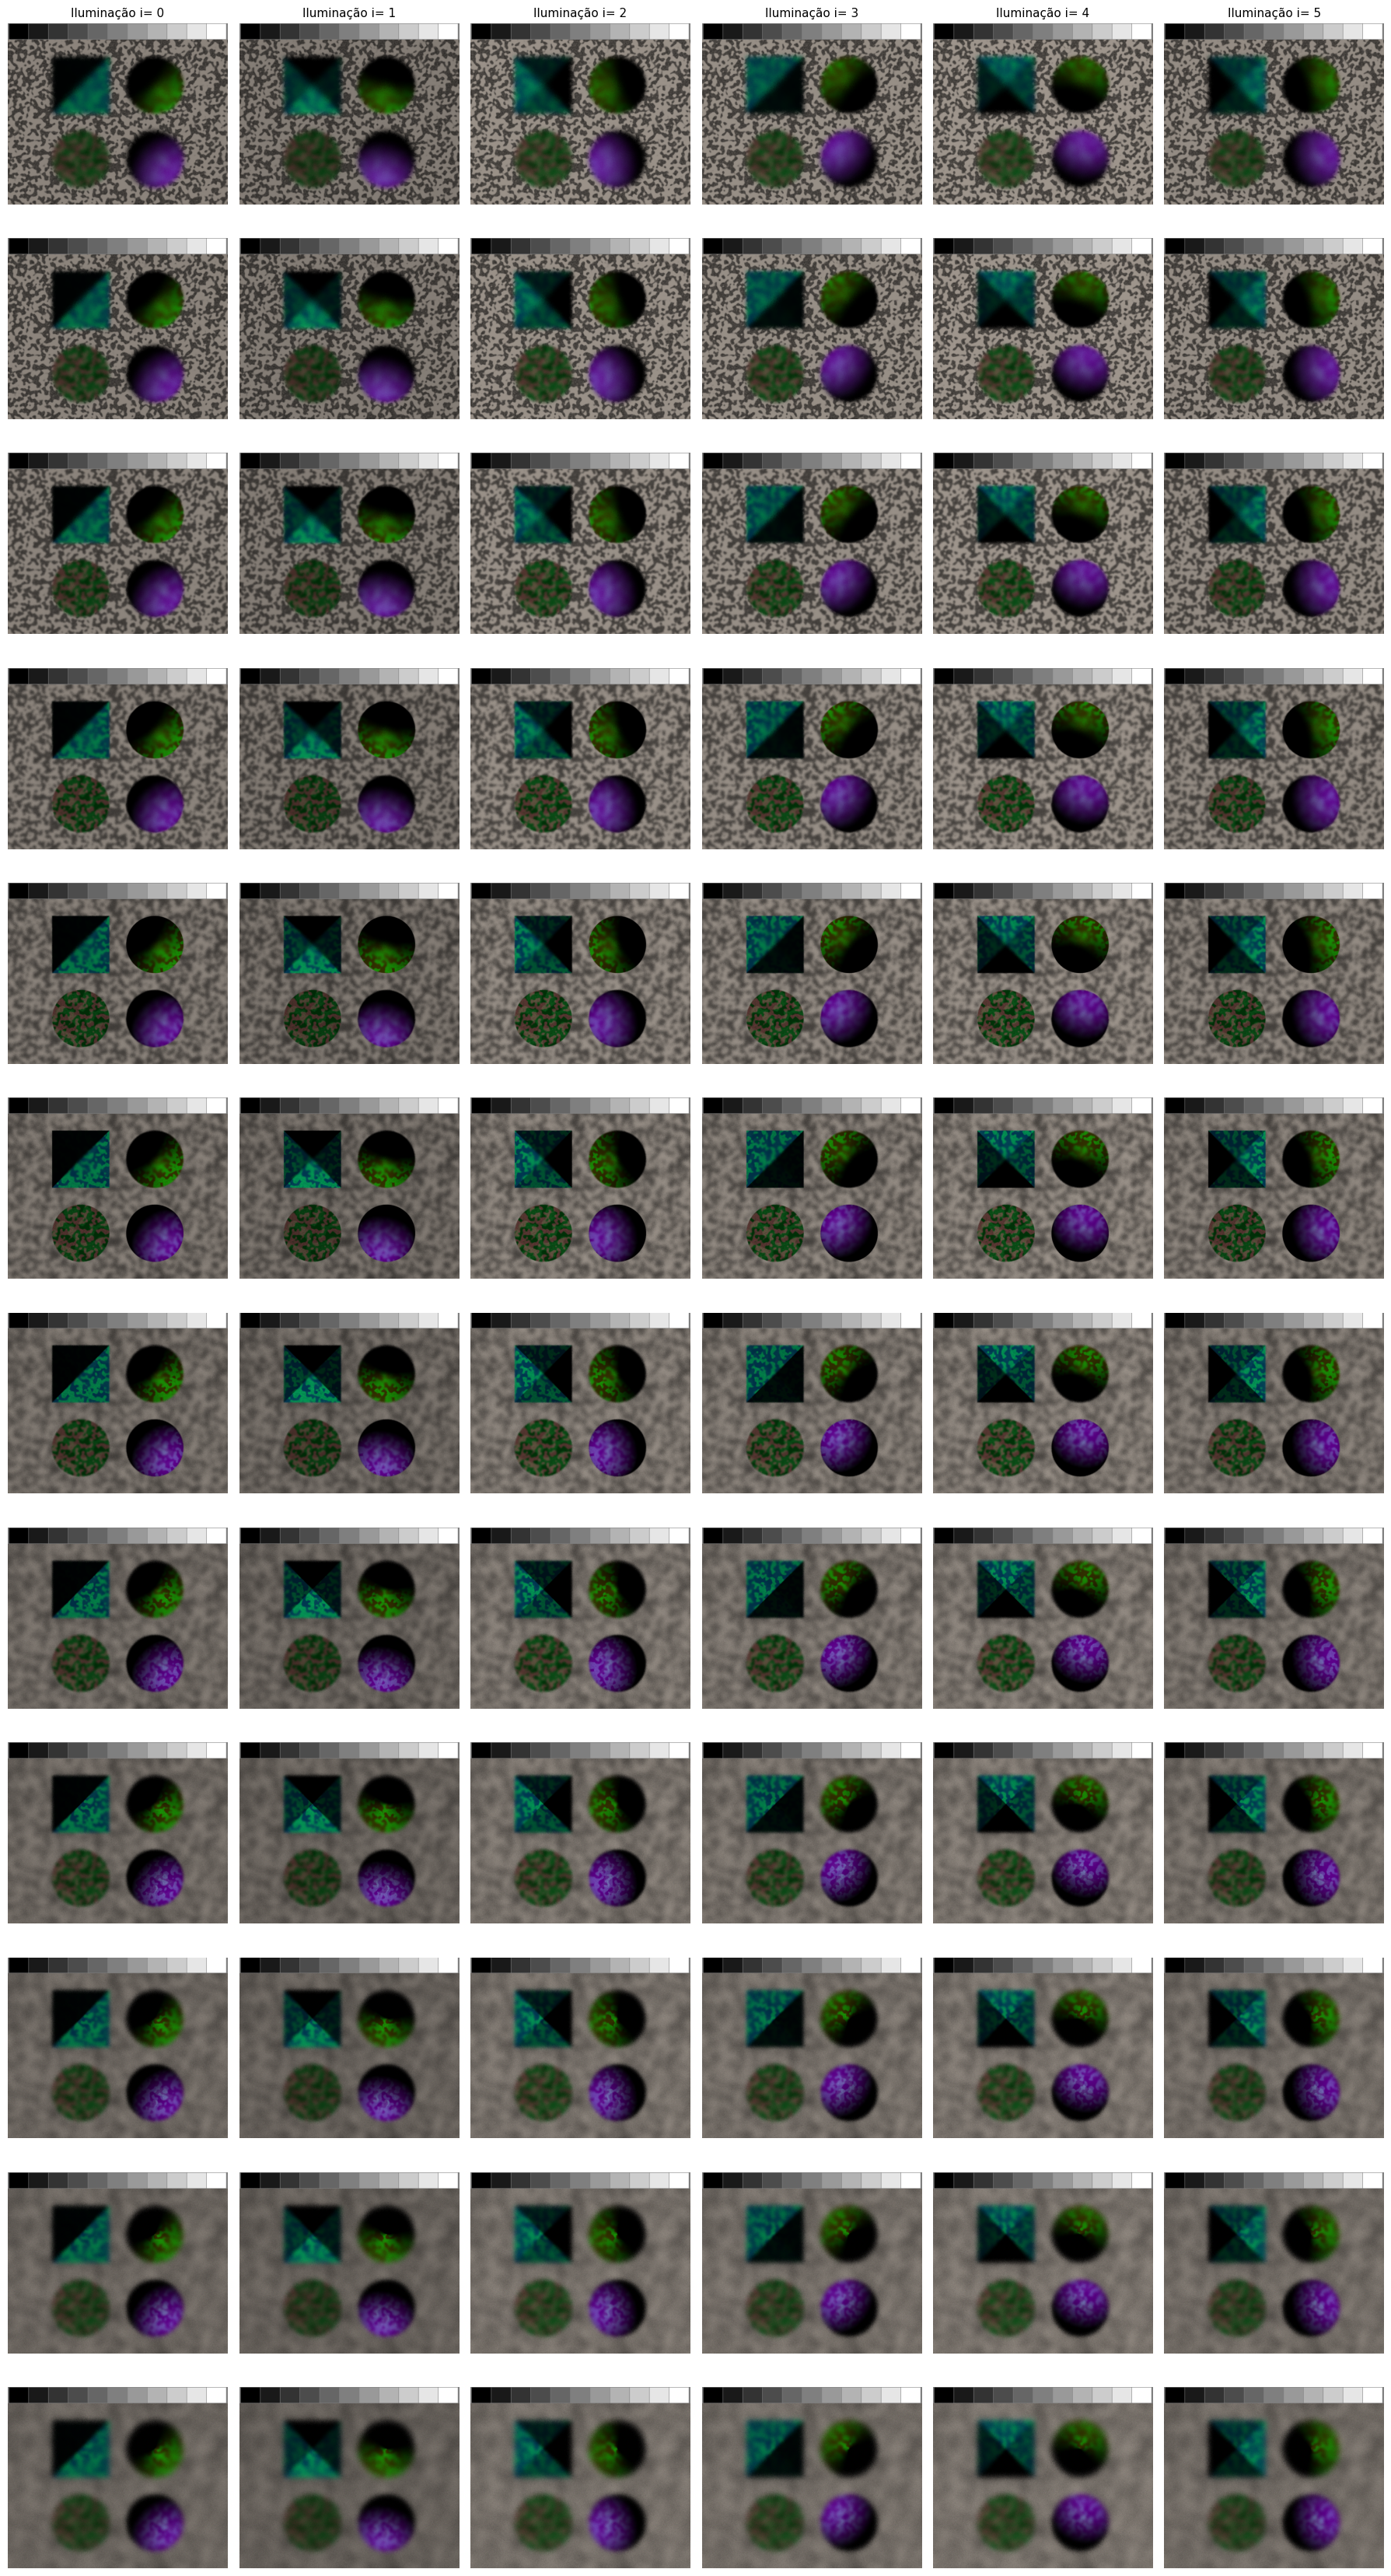

Imagem salva em: grade_6_iluminacoes_variacoes_focais.png


In [3]:
from pathlib import Path
import re
from collections import defaultdict
from PIL import Image

import matplotlib.pyplot as plt

base_dir = Path("/home/lelis/Documents/Projetos/hybrid-stereo-method/data/raw/hybrid_stereo/2025-03-08-stQ-melon24-amb0.00-glo0.50/organized_by_focus")
exts = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

def extrair_indices(path: Path):
    txt = path.as_posix().lower()

    # tenta identificar índice de foco
    m_focus = re.search(r"(?:focus|foco|f)[_\- ]?(\d+)", txt)
    focus = int(m_focus.group(1)) if m_focus else None

    # tenta identificar índice de iluminação
    m_light = re.search(r"(?:illumination|iluminacao|ilum|light|luz|lp|led|l)[_\- ]?(\d+)", txt)
    light = int(m_light.group(1)) if m_light else None

    return focus, light

# Mapeia (focus, light) -> arquivo (primeiro encontrado em ordem)
grid_map = {}
for p in sorted(base_dir.rglob("*")):
    if p.is_file() and p.suffix.lower() in exts:
        focus, light = extrair_indices(p)
        if focus is not None and light is not None:
            grid_map.setdefault((focus, light), p)

if not grid_map:
    raise ValueError("Não foi possível identificar foco/iluminação nos nomes de pastas/arquivos.")

# Seleciona as 6 primeiras iluminações
lights = sorted({l for _, l in grid_map.keys()})[:6]
if len(lights) < 6:
    print(f"Atenção: apenas {len(lights)} iluminações encontradas.")

# Focos disponíveis para as iluminações selecionadas
focuses = sorted({f for (f, l) in grid_map.keys() if l in lights})

# Cria a grade (linhas=foco, colunas=iluminação)
n_rows, n_cols = len(focuses), len(lights)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(3 * n_cols, 2.8 * n_rows), squeeze=False)

for i, f in enumerate(focuses):
    for j, l in enumerate(lights):
        ax = axes[i, j]
        img_path = grid_map.get((f, l), None)

        if img_path is not None:
            img = Image.open(img_path).convert("RGB")
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, "N/A", ha="center", va="center", fontsize=10)

        ax.axis("off")

        if i == 0:
            ax.set_title(f"Iluminação i= {l}", fontsize=11)
        if j == 0:
            ax.set_ylabel(f"Foco {f}", fontsize=11)

# fig.suptitle("6 primeiras iluminações e suas variações focais", fontsize=14, y=0.995)
fig.tight_layout()

out_path = "grade_6_iluminacoes_variacoes_focais.png"
fig.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"Imagem salva em: {out_path}")

[((125, 2), PosixPath('/home/lelis/Documents/Projetos/hybrid-stereo-method/data/raw/hybrid_stereo/2025-03-08-stQ-melon24-amb0.00-glo0.50/organized_by_focus/zf125.0000-df020.0000/L002.png')), ((35, 1), PosixPath('/home/lelis/Documents/Projetos/hybrid-stereo-method/data/raw/hybrid_stereo/2025-03-08-stQ-melon24-amb0.00-glo0.50/organized_by_focus/zf035.0000-df020.0000/L001.png')), ((15, 2), PosixPath('/home/lelis/Documents/Projetos/hybrid-stereo-method/data/raw/hybrid_stereo/2025-03-08-stQ-melon24-amb0.00-glo0.50/organized_by_focus/zf015.0000-df020.0000/L002.png'))]


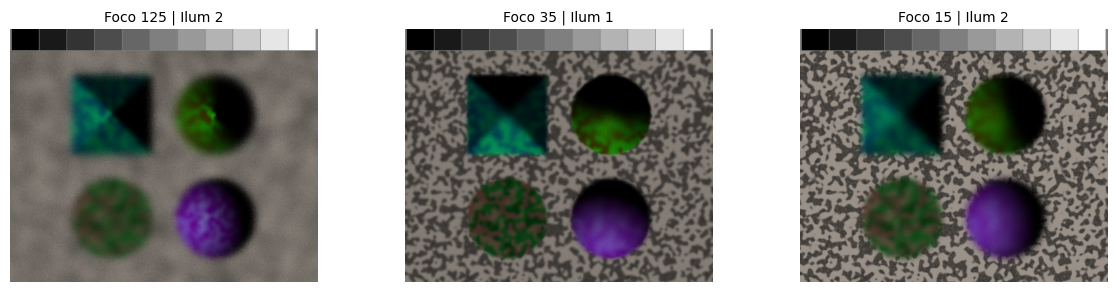

In [13]:
import random

# Seleciona 3 pares (foco, iluminação) aleatórios do mapa já existente
k = min(3, len(grid_map))
amostras = random.sample(list(grid_map.items()), k=k)
print(amostras)
fig, axes = plt.subplots(1, k, figsize=(4 * k, 3), squeeze=False)
axes = axes[0]

for idx, ((foco_idx, luz_idx), caminho_img) in enumerate(amostras):
    ax = axes[idx]
    img = Image.open(caminho_img).convert("RGB")
    ax.imshow(img)
    ax.set_title(f"Foco {foco_idx} | Ilum {luz_idx}", fontsize=10)
    ax.axis("off")


out_path = "linha_3_iluminacoes_variacoes_focais.png"
fig.savefig(out_path, dpi=200, bbox_inches="tight")

fig.tight_layout()
plt.show()

Imagem em foco (final): /home/lelis/Documents/Projetos/hybrid-stereo-method/data/results/hybrid_stereo/20260330_2025_2025-03-08-stQ-melon24-amb0.00-glo0.50/multifocus_stereo/average/iSel.fni
Mapa de profundidade (ref): /home/lelis/Documents/Projetos/hybrid-stereo-method/data/results/hybrid_stereo/20260330_2025_2025-03-08-stQ-melon24-amb0.00-glo0.50/sharp/hAvg.png
Profundidade reconstruída (multifocal): /home/lelis/Documents/Projetos/hybrid-stereo-method/data/results/hybrid_stereo/20260330_2025_2025-03-08-stQ-melon24-amb0.00-glo0.50/multifocus_stereo/average/zMos.fni
Mapa de normal (ref): /home/lelis/Documents/Projetos/hybrid-stereo-method/data/results/hybrid_stereo/20260330_2025_2025-03-08-stQ-melon24-amb0.00-glo0.50/sharp/sNrm.png
Normal photometric: /home/lelis/Documents/Projetos/hybrid-stereo-method/data/results/hybrid_stereo/20260330_2025_2025-03-08-stQ-melon24-amb0.00-glo0.50/photometric_stereo/normal_map.npy
Mapa de altura (ref): /home/lelis/Documents/Projetos/hybrid-stereo-metho

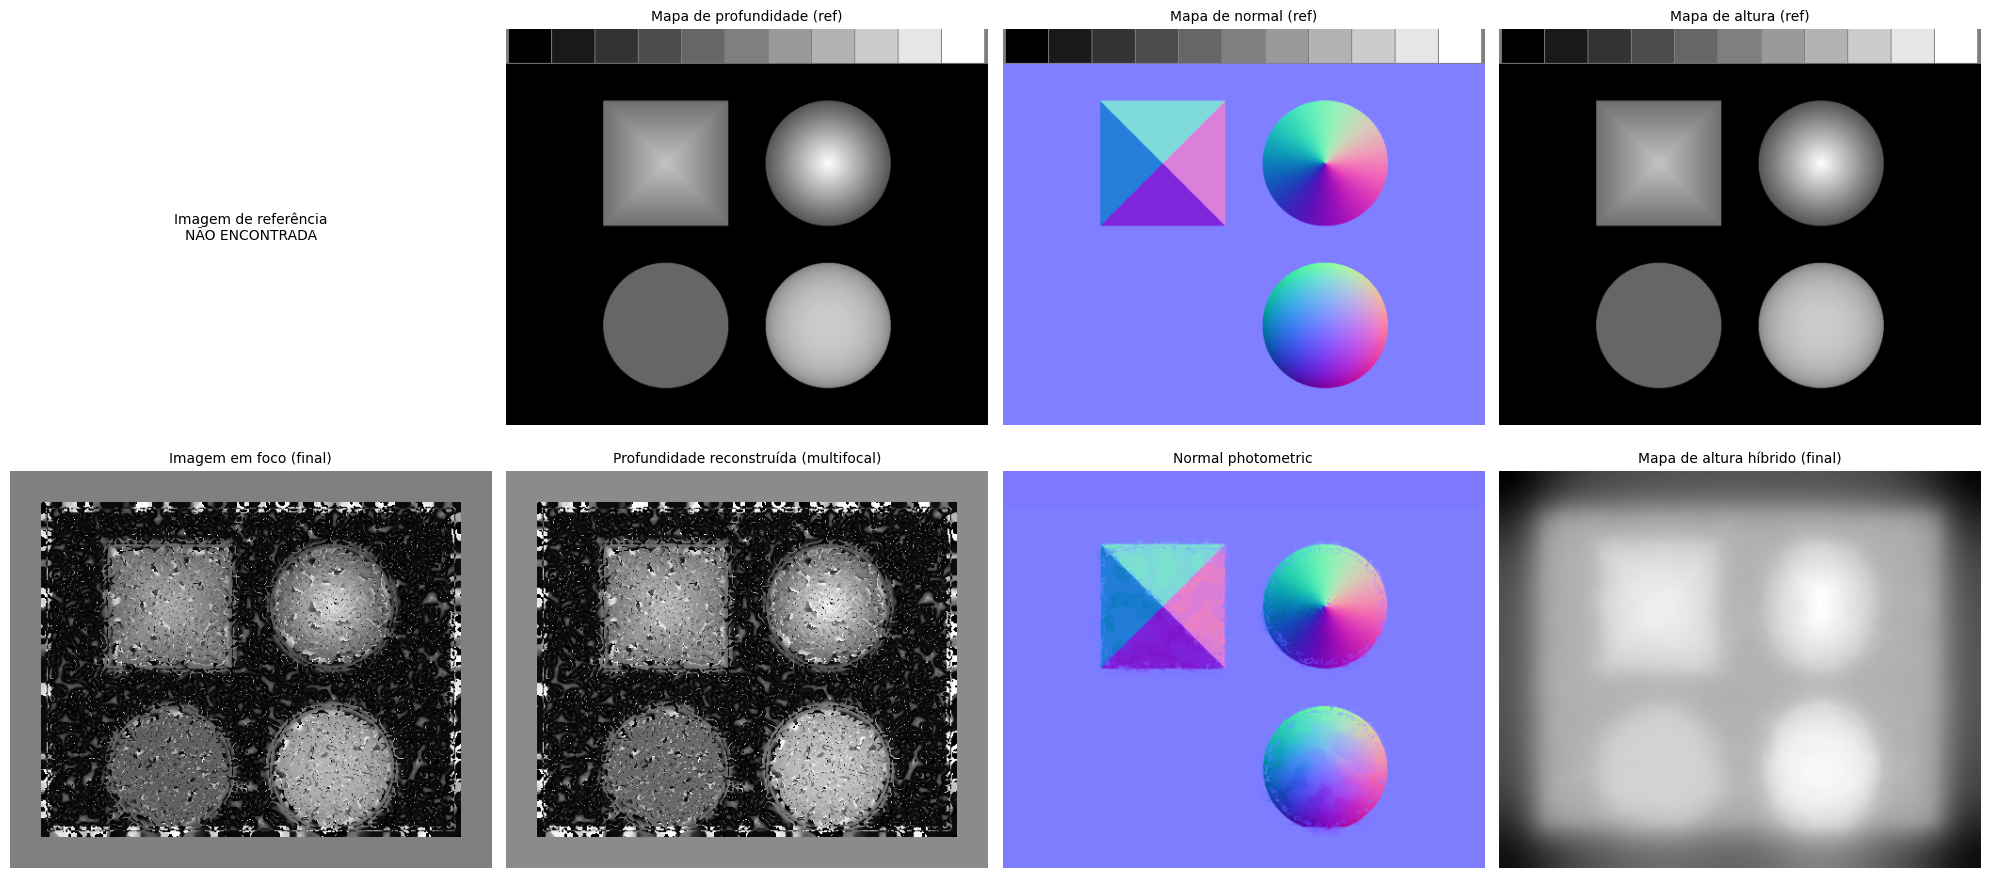


Painel salvo em: /home/lelis/Documents/Projetos/hybrid-stereo-method/data/results/hybrid_stereo/20260330_2025_2025-03-08-stQ-melon24-amb0.00-glo0.50/painel_referencia_multifocal_photometric_hybrid.png


In [17]:
import sys
import numpy as np

# Pasta de resultados alvo
results_dir = base_dir.parents[4] / "data/results/hybrid_stereo/20260330_2025_2025-03-08-stQ-melon24-amb0.00-glo0.50"
if not results_dir.exists():
    raise FileNotFoundError(f"Pasta não encontrada: {results_dir}")

# Usaremos caminhos absolutos baseados na raiz do projeto onde aplicável
project_root = base_dir.parents[4]

# Adiciona o diretório `src` ao PYTHONPATH para podermos importar suas funções
if str(project_root / "src") not in sys.path:
    sys.path.append(str(project_root / "src"))

from hybrid_stereo_method.infrastructure.io.image_io import read_fni_to_image_array

# Seleção das 8 imagens (topo/baixo por coluna)
selected = {
    "Imagem de referência": results_dir / "sharp" / "sRGB.png", # Exemplo de fallback, pode precisar de ajuste
    "Imagem em foco (final)": project_root / "data/results/hybrid_stereo/20260330_2025_2025-03-08-stQ-melon24-amb0.00-glo0.50/multifocus_stereo/average/iSel.fni",
    "Mapa de profundidade (ref)": Path("/home/lelis/Documents/Projetos/hybrid-stereo-method/data/results/hybrid_stereo/20260330_2025_2025-03-08-stQ-melon24-amb0.00-glo0.50/sharp/hAvg.png"),
    "Profundidade reconstruída (multifocal)": project_root / "data/results/hybrid_stereo/20260330_2025_2025-03-08-stQ-melon24-amb0.00-glo0.50/multifocus_stereo/average/zMos.fni",
    "Mapa de normal (ref)": project_root / "data/results/hybrid_stereo/20260330_2025_2025-03-08-stQ-melon24-amb0.00-glo0.50/sharp/sNrm.png",
    "Normal photometric": project_root / "data/results/hybrid_stereo/20260330_2025_2025-03-08-stQ-melon24-amb0.00-glo0.50/photometric_stereo/normal_map.npy",
    "Mapa de altura (ref)": Path("/home/lelis/Documents/Projetos/hybrid-stereo-method/data/results/hybrid_stereo/20260330_2025_2025-03-08-stQ-melon24-amb0.00-glo0.50/sharp/hAvg.png"),
    "Mapa de altura híbrido (final)": project_root / "data/results/hybrid_stereo/20260330_2025_2025-03-08-stQ-melon24-amb0.00-glo0.50/integration/height_map.npy",
}

# Organiza em colunas (topo, baixo) - Atualizado para refletir os novos mapeamentos (Normais no lugar de Gradientes)
pairs = [
    ("Imagem de referência", "Imagem em foco (final)"),
    ("Mapa de profundidade (ref)", "Profundidade reconstruída (multifocal)"),
    ("Mapa de normal (ref)", "Normal photometric"),
    ("Mapa de altura (ref)", "Mapa de altura híbrido (final)"),
]

fig, axes = plt.subplots(2, 4, figsize=(20, 9), squeeze=False)

# Função auxiliar para carregar de extensão arbitrária (.npy, .fni, etc - simplificado)
def carregar_imagem_suportada(p):
    if p.suffix == '.npy':
        arr = np.load(p)
        # Normaliza array NPY para 0-255 se for normal ou profundidade genérica para visualização
        if arr.ndim == 3:
            return ((arr - arr.min()) / (arr.max() - arr.min()) * 255).astype(np.uint8)
        return arr
    elif p.suffix == '.fni':
        return read_fni_to_image_array(p)
    else:
        return Image.open(p)


for col, (top_key, bottom_key) in enumerate(pairs):
    for row, key in enumerate((top_key, bottom_key)):
        ax = axes[row, col]
        p = selected.get(key)

        if p is None or not Path(p).exists():
            ax.text(0.5, 0.5, f"{key}\nNÃO ENCONTRADA", ha="center", va="center", fontsize=10)
            ax.axis("off")
            continue

        im = carregar_imagem_suportada(Path(p))
        if isinstance(im, np.ndarray):
             ax.imshow(im, cmap="gray" if im.ndim == 2 else None)
        else:
            if im.mode in ("L", "I", "I;16", "F"):
                ax.imshow(im, cmap="gray")
            else:
                ax.imshow(im)

        ax.set_title(key, fontsize=10)
        ax.axis("off")

        print(f"{key}: {p}")

fig.tight_layout()
out_path = results_dir / "painel_referencia_multifocal_photometric_hybrid.png"
fig.savefig(out_path, dpi=200, bbox_inches="tight")
plt.show()

print(f"\nPainel salvo em: {out_path}")